Using device: cpu
Analytical torsional constant J = π R⁴/2 = 1.570796e-04

Training started...
Epoch     1 | total = 4.4461e+00 | res = 4.1274e+00 | bnd = 3.1878e-06
Epoch   500 | total = 6.3429e-01 | res = 1.0858e-01 | bnd = 5.2572e-06
Epoch  1000 | total = 2.1450e-03 | res = 1.3948e-03 | bnd = 7.5019e-09
Epoch  1500 | total = 1.0620e-03 | res = 1.0493e-03 | bnd = 1.2636e-10
Epoch  2000 | total = 6.9571e-04 | res = 6.8609e-04 | bnd = 9.6152e-11
Epoch  2500 | total = 1.4067e-02 | res = 4.3462e-04 | bnd = 1.3633e-07
Epoch  3000 | total = 3.0506e-04 | res = 2.9876e-04 | bnd = 6.3072e-11
Epoch  3500 | total = 2.4602e-04 | res = 2.4019e-04 | bnd = 5.8280e-11
Epoch  4000 | total = 2.1824e-04 | res = 2.1256e-04 | bnd = 5.6818e-11
Epoch  4500 | total = 2.0639e-04 | res = 2.0087e-04 | bnd = 5.5226e-11
Epoch  5000 | total = 2.0075e-04 | res = 1.9525e-04 | bnd = 5.4932e-11
Training finished.

Torsional constant (PINN)       : 1.575971e-04
Torsional constant (Analytical) : 1.570796e-04
Relative e

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/pinn_circular_results.png'

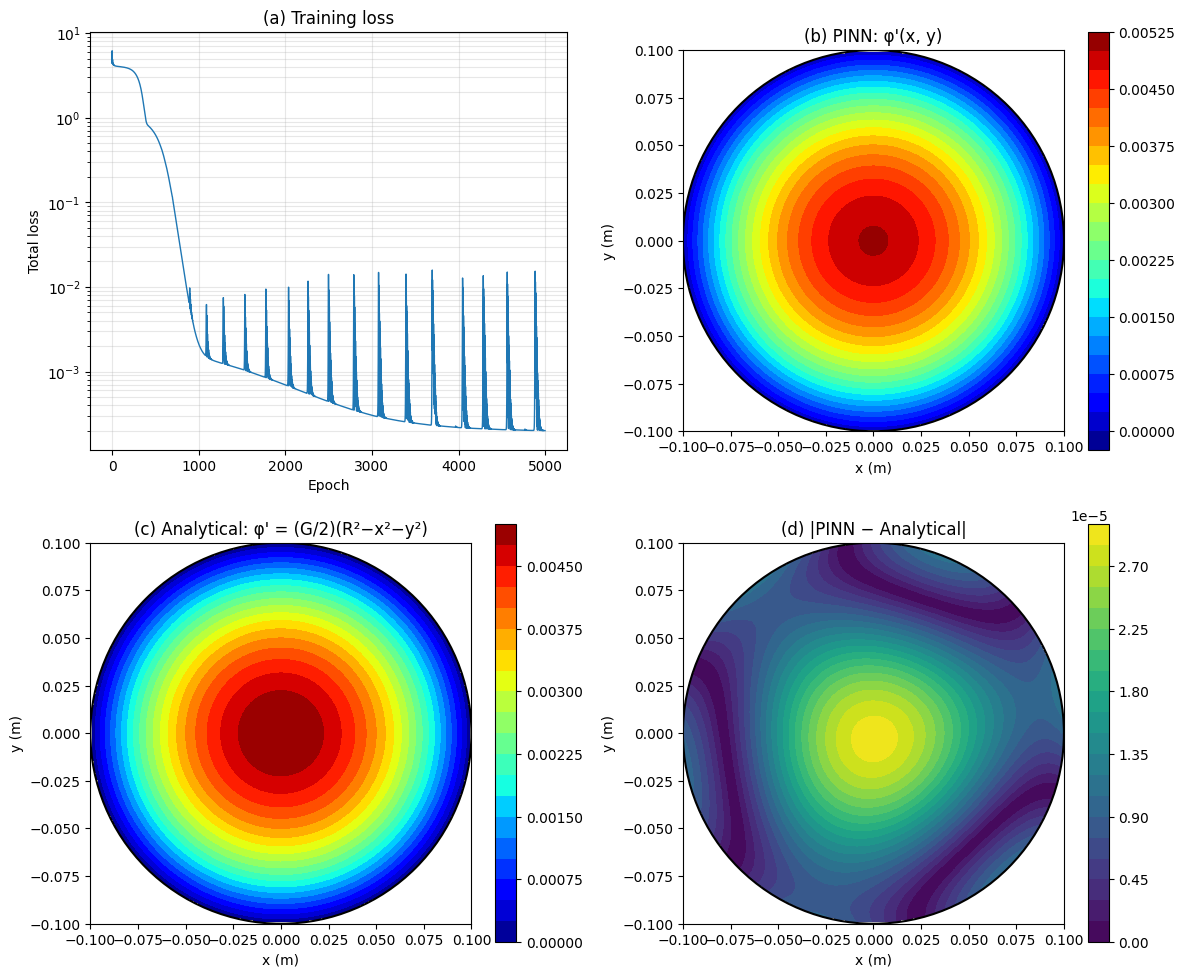

In [ ]:
"""
PINN for 2D Saint-Venant Torsion Problem (Circular Cross-Section)
==================================================================
Reference: Jo et al. (2026), "Task-aware evolution in physics-informed
           neural networks: Application to Saint-Venant torsion problems",
           Engineering Applications of Artificial Intelligence 168, 113988.

Section 6.1: 2D Poisson equation with scaled Prandtl stress function
    PDE      : ∇²φ'(x, y) = -2G          on Ω  (Eq. 29)
    BC       : φ'(x, y) = 0              on ∂Ω
    Geometry : Circle of diameter 0.2 m  (radius R = 0.1 m), centered at (0, 0)
    Output   : Torsional constant J = (2/G) ∫∫_A φ'(x, y) dA   (Eq. 30)

Network setup follows Table 1 / Section 7.2:
    - 5 hidden layers, 8 neurons per layer
    - GELU activation
    - Adamax optimizer
    - Loss weights: λ_r = 1, λ_b = 1e5
    - ~10,000 epochs
"""

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Reproducibility & device
# ----------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# Physical parameters
# ----------------------------------------------------------------------
G = 1.0           # Shear modulus (normalized; analytical J does not depend on G)
R = 0.1           # Radius of the circular cross-section (m), diameter = 0.2 m

# Analytical reference for a solid circular cross-section
# φ'_exact(x, y) = (G/2) * (R² - x² - y²),  J_exact = π R⁴ / 2
J_analytical = np.pi * R**4 / 2.0
print(f"Analytical torsional constant J = π R⁴/2 = {J_analytical:.6e}")


# ----------------------------------------------------------------------
# 1. Neural network: 5 hidden layers, 8 neurons each, GELU activation
# ----------------------------------------------------------------------
class PINN(nn.Module):
    def __init__(self, n_hidden_layers=5, n_neurons=8):
        super().__init__()
        layers = [nn.Linear(2, n_neurons), nn.GELU()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(n_neurons, n_neurons), nn.GELU()]
        layers += [nn.Linear(n_neurons, 1)]
        self.net = nn.Sequential(*layers)

        # Xavier initialization works well with GELU/tanh activations
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        return self.net(inp)


# ----------------------------------------------------------------------
# 2. Sampling collocation points (interior + boundary)
# ----------------------------------------------------------------------
def sample_interior(n_points, R):
    """Uniformly sample points inside the disk of radius R using polar coords."""
    # r = R * sqrt(u) gives uniform distribution over the disk area
    u = np.random.rand(n_points)
    theta = 2.0 * np.pi * np.random.rand(n_points)
    r = R * np.sqrt(u)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x.reshape(-1, 1), y.reshape(-1, 1)


def sample_boundary(n_points, R):
    """Uniformly sample points on the circle r = R."""
    theta = 2.0 * np.pi * np.random.rand(n_points)
    x = R * np.cos(theta)
    y = R * np.sin(theta)
    return x.reshape(-1, 1), y.reshape(-1, 1)


# Roughly match the ANSYS 0.005 m grid density used in the paper.
# Disk area ≈ π(0.1)² ≈ 0.0314 m² ⇒ ~1250 interior cells; circumference 2πR
# with spacing 0.005 ⇒ ~125 boundary points.
N_interior = 2000
N_boundary = 200

x_int_np, y_int_np = sample_interior(N_interior, R)
x_bnd_np, y_bnd_np = sample_boundary(N_boundary, R)

# Convert to torch tensors. Interior points need requires_grad for autodiff.
x_int = torch.tensor(x_int_np, dtype=torch.float32, device=device, requires_grad=True)
y_int = torch.tensor(y_int_np, dtype=torch.float32, device=device, requires_grad=True)
x_bnd = torch.tensor(x_bnd_np, dtype=torch.float32, device=device)
y_bnd = torch.tensor(y_bnd_np, dtype=torch.float32, device=device)


# ----------------------------------------------------------------------
# 3. PDE residual via automatic differentiation
# ----------------------------------------------------------------------
def pde_residual(model, x, y, G):
    """Residual of  ∇²φ'(x, y) + 2G = 0   (Eq. 31)."""
    phi = model(x, y)

    # First derivatives
    phi_x = torch.autograd.grad(phi, x, torch.ones_like(phi), create_graph=True)[0]
    phi_y = torch.autograd.grad(phi, y, torch.ones_like(phi), create_graph=True)[0]

    # Second derivatives
    phi_xx = torch.autograd.grad(phi_x, x, torch.ones_like(phi_x), create_graph=True)[0]
    phi_yy = torch.autograd.grad(phi_y, y, torch.ones_like(phi_y), create_graph=True)[0]

    return phi_xx + phi_yy + 2.0 * G  # = 0 when PDE is satisfied


# ----------------------------------------------------------------------
# 4. Training
# ----------------------------------------------------------------------
model = PINN(n_hidden_layers=5, n_neurons=8).to(device)
optimizer = torch.optim.Adamax(model.parameters(), lr=1e-3)

# Loss weights from the paper
lambda_r = 1.0
lambda_b = 1.0e5

n_epochs = 5000
loss_history = []

print("\nTraining started...")
for epoch in range(n_epochs):
    optimizer.zero_grad()

    # PDE residual loss on interior points
    res = pde_residual(model, x_int, y_int, G)
    loss_r = torch.mean(res ** 2)

    # Boundary loss: φ' = 0 on ∂Ω
    phi_b = model(x_bnd, y_bnd)
    loss_b = torch.mean(phi_b ** 2)

    loss = lambda_r * loss_r + lambda_b * loss_b
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 500 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:5d} | total = {loss.item():.4e} "
              f"| res = {loss_r.item():.4e} | bnd = {loss_b.item():.4e}")

print("Training finished.\n")


# ----------------------------------------------------------------------
# 5. Evaluation: contour, surface, torsional constant
# ----------------------------------------------------------------------
model.eval()

# Evaluation grid (mask out points outside the disk)
n_grid = 200
xs = np.linspace(-R, R, n_grid)
ys = np.linspace(-R, R, n_grid)
X, Y = np.meshgrid(xs, ys)
mask = X**2 + Y**2 <= R**2

x_eval = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=device)
y_eval = torch.tensor(Y.reshape(-1, 1), dtype=torch.float32, device=device)

with torch.no_grad():
    phi_pred = model(x_eval, y_eval).cpu().numpy().reshape(n_grid, n_grid)
phi_pred = np.where(mask, phi_pred, np.nan)

# Analytical solution for comparison
phi_exact = np.where(mask, (G / 2.0) * (R**2 - X**2 - Y**2), np.nan)

# Torsional constant via Monte Carlo integration of φ' over the disk
# J = (2/G) ∫∫_A φ' dA  ;  area of disk = π R²
n_mc = 200_000
xm_np, ym_np = sample_interior(n_mc, R)
xm = torch.tensor(xm_np, dtype=torch.float32, device=device)
ym = torch.tensor(ym_np, dtype=torch.float32, device=device)
with torch.no_grad():
    phi_mc = model(xm, ym).cpu().numpy().flatten()
area = np.pi * R**2
J_pinn = (2.0 / G) * np.mean(phi_mc) * area

rel_err_J = abs(J_pinn - J_analytical) / J_analytical * 100.0
print(f"Torsional constant (PINN)       : {J_pinn:.6e}")
print(f"Torsional constant (Analytical) : {J_analytical:.6e}")
print(f"Relative error                  : {rel_err_J:.3f} %")


# ----------------------------------------------------------------------
# 6. Plots
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Training loss
ax = axes[0, 0]
ax.semilogy(loss_history, lw=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Total loss")
ax.set_title("(a) Training loss")
ax.grid(True, which="both", alpha=0.3)

# (b) PINN contour
ax = axes[0, 1]
cf = ax.contourf(X, Y, phi_pred, levels=20, cmap="jet")
ax.add_patch(plt.Circle((0, 0), R, fill=False, color="k", lw=1.5))
ax.set_aspect("equal")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("(b) PINN: φ'(x, y)")
plt.colorbar(cf, ax=ax)

# (c) Analytical contour
ax = axes[1, 0]
cf = ax.contourf(X, Y, phi_exact, levels=20, cmap="jet")
ax.add_patch(plt.Circle((0, 0), R, fill=False, color="k", lw=1.5))
ax.set_aspect("equal")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("(c) Analytical: φ' = (G/2)(R²−x²−y²)")
plt.colorbar(cf, ax=ax)

# (d) Absolute error
ax = axes[1, 1]
err = np.abs(phi_pred - phi_exact)
cf = ax.contourf(X, Y, err, levels=20, cmap="viridis")
ax.add_patch(plt.Circle((0, 0), R, fill=False, color="k", lw=1.5))
ax.set_aspect("equal")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("(d) |PINN − Analytical|")
plt.colorbar(cf, ax=ax)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/pinn_circular_results.png", dpi=150)
plt.close()
print("\nFigure saved to: /mnt/user-data/outputs/pinn_circular_results.png")

NameError: name 'X' is not defined

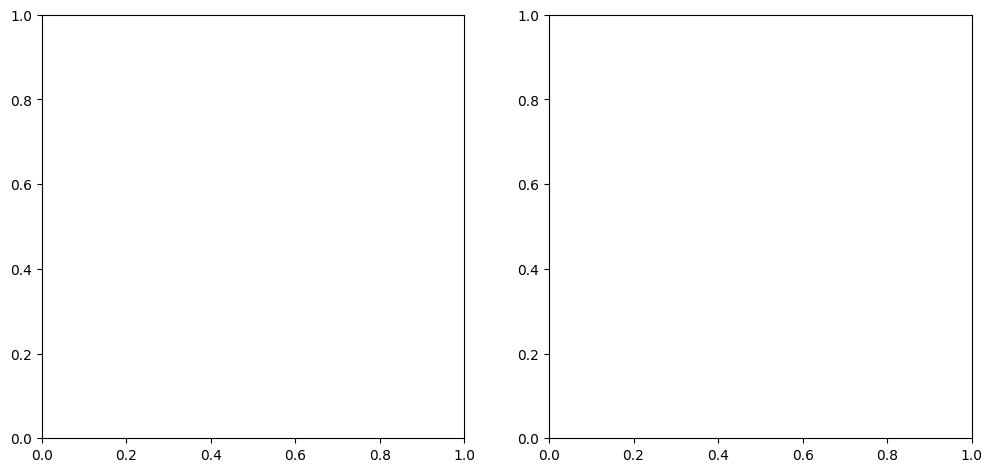

In [ ]:
import matplotlib.pyplot as plt
# Left: Analytical (reference, plays the role of "ANSYS" in paper Fig. 9A)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
ax = axes[0]
cf1 = ax.contourf(X, Y, phi_exact, levels=levels, cmap="jet",
                  vmin=vmin, vmax=vmax)
ax.contour(X, Y, phi_exact, levels=10, colors="k", linewidths=0.4, alpha=0.5)
ax.add_patch(plt.Circle((0, 0), R, fill=False, color="k", lw=1.5))
ax.set_aspect("equal")
ax.set_xlim(-R*1.1, R*1.1); ax.set_ylim(-R*1.1, R*1.1)
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("Analytical  φ'(x, y) = (G/2)(R² − x² − y²)")
plt.colorbar(cf1, ax=ax, fraction=0.046, pad=0.04, label="φ'")

# Right: PINN prediction
ax = axes[1]
cf2 = ax.contourf(X, Y, phi_pred, levels=levels, cmap="jet",
                  vmin=vmin, vmax=vmax)
ax.contour(X, Y, phi_pred, levels=10, colors="k", linewidths=0.4, alpha=0.5)
ax.add_patch(plt.Circle((0, 0), R, fill=False, color="k", lw=1.5))
ax.set_aspect("equal")
ax.set_xlim(-R*1.1, R*1.1); ax.set_ylim(-R*1.1, R*1.1)
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_title("PINN  φ'(x, y)")
plt.colorbar(cf2, ax=ax, fraction=0.046, pad=0.04, label="φ'")

fig.suptitle("Comparison of Prandtl stress function field: Analytical vs PINN  (Circular)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/pinn_circular_contour.png",
            dpi=150, bbox_inches="tight")
plt.close()